#Importing Modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Loading Dataset

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.shape

(891, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


#Handling Missing Values

In [5]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [12]:
df['Age'] = df['Age'].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df.drop(columns=["Cabin"], inplace=True)

In [6]:
df.duplicated().sum()

np.int64(0)

#How many passengers survived?

In [7]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [8]:
df['Survived'].value_counts(normalize=True)*100

,proportion
Survived,
0,61.616162
1,38.383838


In [9]:
df['survival_status'] = df['Survived'].map({
    0: 'Not Survived',
    1: 'Survived'
})

In [10]:
df[["Survived", "survival_status"]].head()

,Survived,survival_status
0,0,Not Survived
1,1,Survived
2,1,Survived
3,1,Survived
4,0,Not Survived


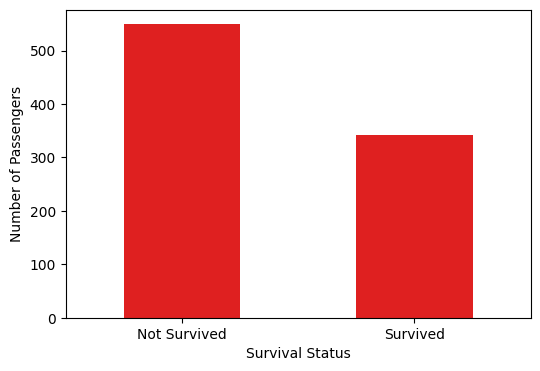

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(df, x="survival_status", color='red', width=0.5)
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")
plt.show()

#Observation
###Most passengers did not survive the Titanic disaster. The number of non-survivors is higher than survivors.

#Survival Analysis By Gender

In [14]:
df["Sex"].value_counts()

,count
Sex,
male,577
female,314


In [15]:
pd.crosstab(df["Sex"], df["survival_status"])

survival_status,Not Survived,Survived
Sex,,
female,81,233
male,468,109


In [16]:
gender_survival_rate = df.groupby("Sex")["Survived"].mean() * 100
gender_survival_rate

,Survived
Sex,
female,74.203822
male,18.890815


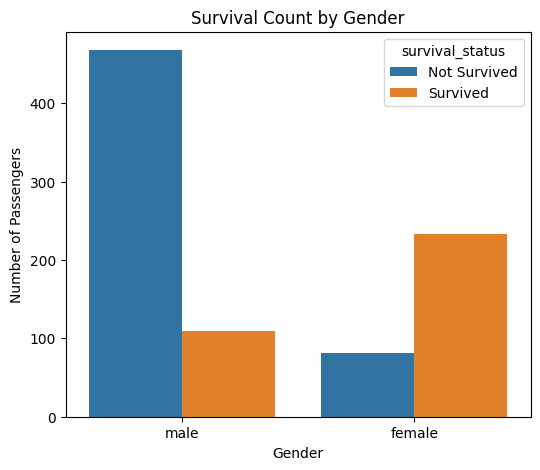

In [17]:
plt.figure(figsize=(6,5))
sns.countplot(df, x='Sex', hue="survival_status")
plt.title("Survival Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.show()

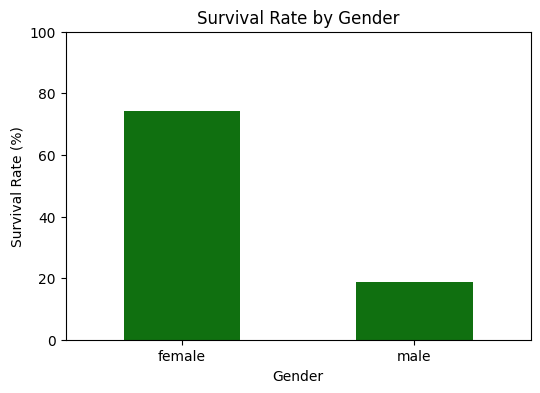

In [18]:
plt.figure(figsize=(6,4))
sns.barplot(
    x=gender_survival_rate.index,
    y=gender_survival_rate.values,
    width=0.5,
    color='green'
)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.show()

#Insight:
### The survival rate of females is significantly higher than males. This may be because women and children were given priority during rescue. Therefore, Sex is one of the most important features for predicting survival.

#Survival Analysis By Pclass

In [19]:
df['Pclass'].value_counts()

,count
Pclass,
3,491
1,216
2,184


In [20]:
pd.crosstab(df['Pclass'], df['Survived'])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


In [21]:
class_survival_rate = df.groupby('Pclass')['Survived'].mean()*100
class_survival_rate

,Survived
Pclass,
1,62.962963
2,47.282609
3,24.236253


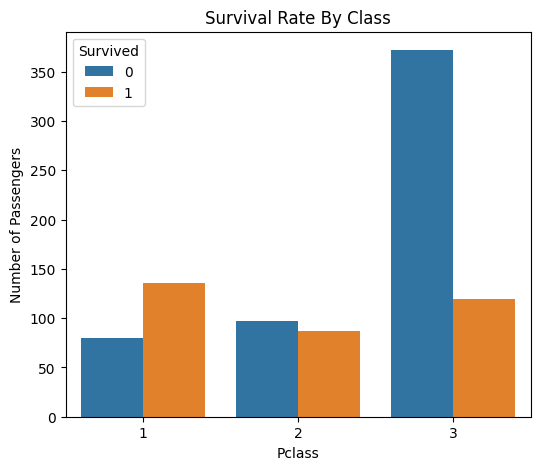

In [22]:
plt.figure(figsize=(6,5))
sns.countplot(df, x="Pclass", hue='Survived')
plt.title("Survival Rate By Class")
plt.xlabel("Pclass")
plt.ylabel("Number of Passengers")
plt.show()

#Insight:
###Passenger class strongly affected survival. Higher-class passengers had better survival chances, possibly because their cabins were closer to lifeboats or they received rescue priority. Therefore, Pclass is an important feature for survival analysis.

#Survival Analysis By Gender and Pclass

In [23]:
pd.crosstab(
    [df["Sex"], df["Pclass"]],
    df["survival_status"]
)

survival_status  Not Survived  Survived
Sex    Pclass                          
female 1                    3        91
       2                    6        70
       3                   72        72
male   1                   77        45
       2                   91        17
       3                  300        47

In [24]:
gender_class_survival = (
    df.groupby([df['Sex'], df['Pclass']])['Survived']
    .mean()
    .mul(100)
    .round(2)
)
gender_class_survival

Sex     Pclass
female  1         96.81
        2         92.11
        3         50.00
male    1         36.89
        2         15.74
        3         13.54
Name: Survived, dtype: float64

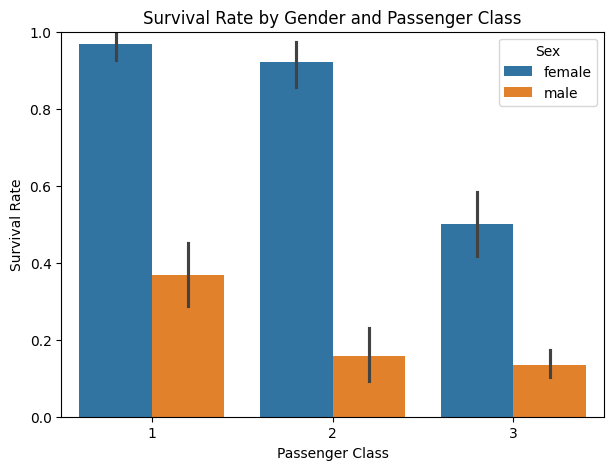

In [25]:
plt.figure(figsize=(7,5))
sns.barplot(df, x='Pclass', y='Survived', hue='Sex')
plt.title("Survival Rate by Gender and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

#Insight:
### Survival was strongly affected by both gender and passenger class. Females were more likely to survive than males, and passengers in higher classes had better survival chances. The combination of being female and in first or second class gave the highest survival probability.

#Survival By Age

In [26]:
df['Age'].describe()

,Age
count,891.000000
mean,29.361582
std,13.019697
min,0.420000
25%,22.000000
50%,28.000000
75%,35.000000
max,80.000000


In [27]:
df.groupby("survival_status")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
survival_status,,,,,,,,
Not Survived,549.0,30.028233,12.499986,1.00,23.0,28.0,35.0,74.0
Survived,342.0,28.291433,13.764425,0.42,21.0,28.0,35.0,80.0


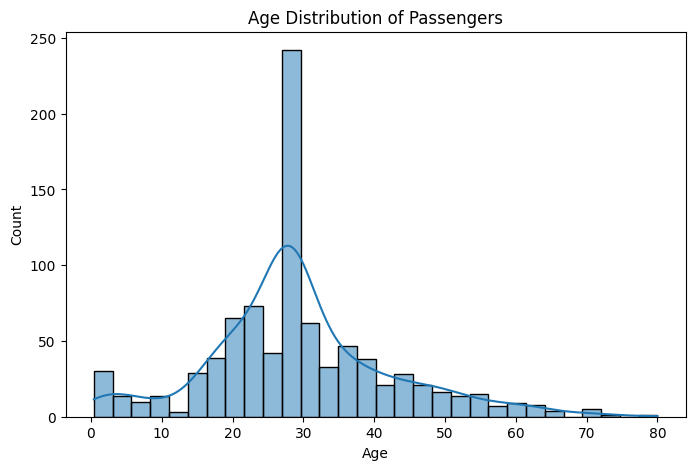

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Age", bins=30, kde=True)
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

#Observation
### The age distribution shows that most Titanic passengers were young adults, especially between the age group of 20 to 40 years. Very few passengers were senior citizens. The dataset also contains children and teenagers, but their count is lower compared to adults.

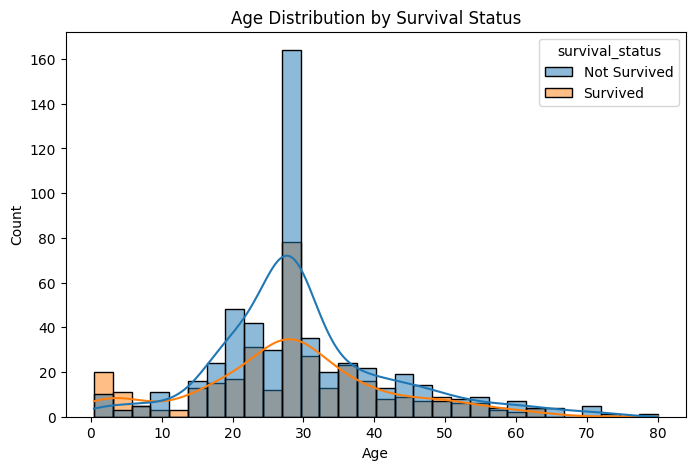

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Age", hue="survival_status", bins=30, kde=True)
plt.title("Age Distribution by Survival Status")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

#Observation
### The age distribution shows that most passengers were young adults, mainly between 20 and 35 years. A large spike is visible around age 28 because missing Age values were filled using the median. In most adult age ranges, the number of non-survivors is higher than survivors. Children show a noticeable survival count, while older passengers were fewer in number and had lower survival counts.

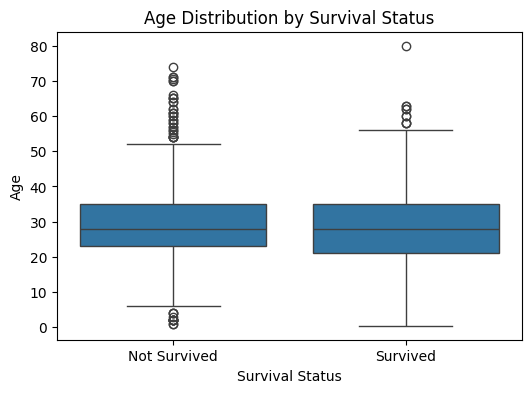

In [30]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="survival_status", y="Age")
plt.title("Age Distribution by Survival Status")
plt.xlabel("Survival Status")
plt.ylabel("Age")
plt.show()

In [31]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teenager", "Young Adult", "Adult", "Senior"]
)

In [32]:
df["Age_Group"].value_counts()

,count
Age_Group,
Young Adult,535
Adult,195
Teenager,70
Child,69
Senior,22


In [33]:
age_group_survival = (
    df.groupby("Age_Group", observed=True)["Survived"]
    .mean()
    .mul(100)
    .round(2)
)

age_group_survival

,Survived
Age_Group,
Child,57.97
Teenager,42.86
Young Adult,35.33
Adult,40.00
Senior,22.73


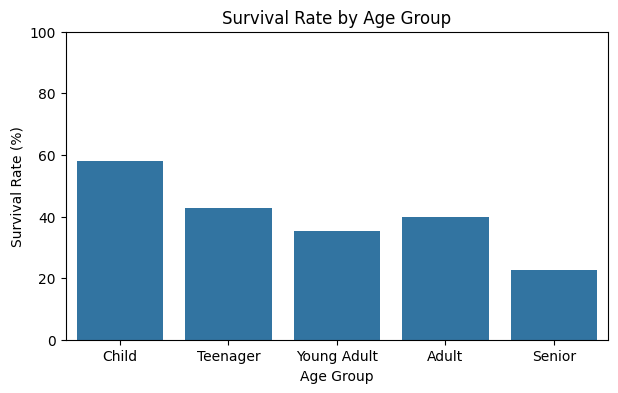

In [34]:
plt.figure(figsize=(7,4))
sns.barplot(
    x=age_group_survival.index,
    y=age_group_survival.values
)

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.show()

#Observation
### When comparing age with survival, children had a better survival rate compared to many adult age groups. This suggests that younger passengers, especially children, may have been given priority during rescue operations.
### Senior passengers had a lower survival rate compared to children. This indicates that older passengers were less likely to survive, possibly because of physical difficulty during evacuation or lower rescue priority.

#Which port had the highest number of passengers?

In [35]:
df['Embarked'].value_counts()

,count
Embarked,
S,646
C,168
Q,77


#Observation
### Most passengers boarded from Southampton. Out of all three embarkation ports, Southampton had the highest passenger count with 646 passengers, followed by Cherbourg with 168 passengers and Queenstown with 77 passengers.

#Which port had the highest survival rate?

In [36]:
df.groupby('Embarked')['Survived'].mean().mul(100).round(2)

,Survived
Embarked,
C,55.36
Q,38.96
S,33.90


#Observation
### Passengers who boarded from Cherbourg had the highest survival rate at 55.36%. Queenstown passengers had a survival rate of 38.96%, while Southampton passengers had the lowest survival rate at 33.90%.

#Insight:
###Embarked port appears to be related to survival. Passengers from Cherbourg had better survival chances compared to passengers from Queenstown and Southampton. However, this may be because many Cherbourg passengers belonged to higher passenger classes or paid higher fares, so we should analyze Embarked together with Pclass and Fare before making a final conclusion.

#Are passengers from one port mostly from a specific passenger class?

In [37]:
pd.crosstab(df['Embarked'], df['Pclass'], normalize="index") * 100

Pclass,1,2,3
Embarked,,,
C,50.595238,10.119048,39.285714
Q,2.597403,3.896104,93.506494
S,19.969040,25.386997,54.643963


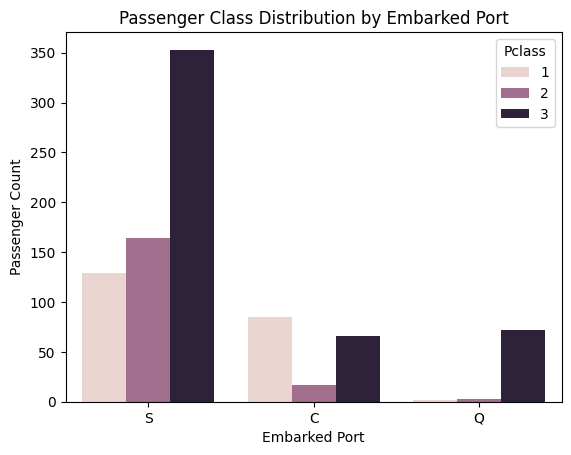

In [38]:
sns.countplot(data=df, x="Embarked", hue="Pclass")
plt.title("Passenger Class Distribution by Embarked Port")
plt.xlabel("Embarked Port")
plt.ylabel("Passenger Count")
plt.show()

#Observation:
### The passenger class distribution differs strongly by embarked port. Cherbourg had the highest proportion of 1st class passengers at around 50.60%, while Queenstown had mostly 3rd class passengers at around 93.51%. Southampton also had a majority of 3rd class passengers at around 54.64%. This suggests that Cherbourg's higher survival rate may be related to its higher percentage of 1st class passengers rather than the port itself.

#Insight:
###Embarked port is connected with passenger class. Since 1st class passengers had better survival chances, Cherbourg’s higher survival rate can be partly explained by the fact that more than half of its passengers were from 1st class.

In [39]:
pd.crosstab(df["Embarked"], df["Sex"], normalize="index") * 100

Sex,female,male
Embarked,,
C,43.452381,56.547619
Q,46.753247,53.246753
S,31.733746,68.266254


#Insight:
### Queenstown had a slightly higher survival rate than Southampton even though most Queenstown passengers were from 3rd class. This can be explained by the higher proportion of female passengers in Queenstown compared to Southampton. Since female passengers had much higher survival chances, Queenstown’s survival rate became higher. Also, Queenstown had a smaller passenger count, so its survival percentage was more sensitive to small changes.

#Survival By Fare

##Did passengers who paid higher fare have better survival chances?

In [40]:
df['Fare'].describe()

,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


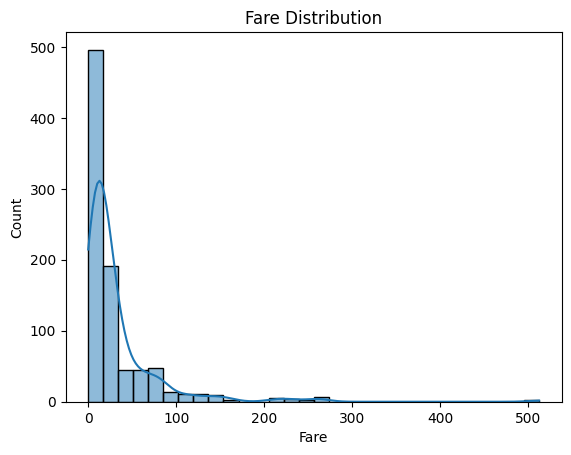

In [41]:
sns.histplot(data=df, x="Fare", bins=30, kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.show()

###Most passengers paid low fares, mostly below 50. Very few passengers paid very high fares, above 100, 200, or even 500.

In [42]:
df.groupby("survival_status")["Fare"].describe()

,count,mean,std,min,25%,50%,75%,max
survival_status,,,,,,,,
Not Survived,549.0,22.117887,31.388207,0.0,7.8542,10.5,26.0,263.0000
Survived,342.0,48.395408,66.596998,0.0,12.4750,26.0,57.0,512.3292


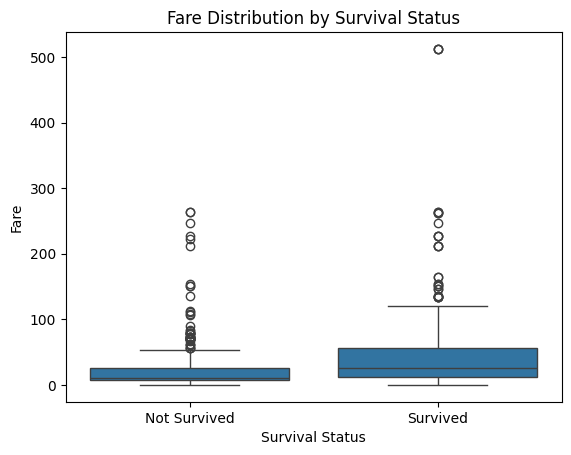

In [43]:
sns.boxplot(data=df, x="survival_status", y="Fare")
plt.title("Fare Distribution by Survival Status")
plt.xlabel("Survival Status")
plt.ylabel("Fare")
plt.show()

### Survivors generally had higher ticket fares. Non-survivors were mostly concentrated in lower fare values.

In [44]:
df["Fare_Group"] = pd.cut(
    df["Fare"],
    bins=[0, 10, 30, 60, 100, 600],
    labels=["Very Low", "Low", "Medium", "High", "Very High"],
    include_lowest=True
)

In [45]:
df["Fare_Group"].value_counts()

,count
Fare_Group,
Very Low,336
Low,321
Medium,112
High,69
Very High,53


In [46]:
fare_survival = (
    df.groupby("Fare_Group", observed=True)["Survived"]
    .mean()
    .mul(100)
    .round(2)
)

fare_survival

,Survived
Fare_Group,
Very Low,19.94
Low,43.30
Medium,48.21
High,62.32
Very High,73.58


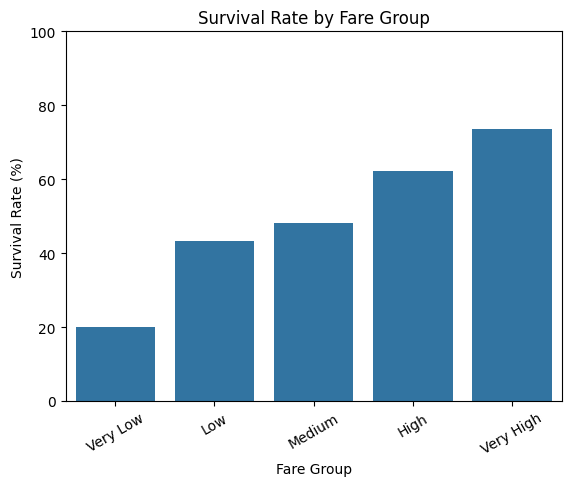

In [47]:
sns.barplot(
    x=fare_survival.index,
    y=fare_survival.values
)

plt.title("Survival Rate by Fare Group")
plt.xlabel("Fare Group")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.xticks(rotation=30)
plt.show()

#Observation:
### Fare distribution is highly right-skewed, meaning most passengers paid low fares while only a few paid very high fares. Survivors had a higher average and median fare compared to non-survivors. The survival rate also increased as fare group increased, from around 19.94% in the very low fare group to around 73.58% in the very high fare group.

### Fare appears to be strongly related to survival. Passengers who paid higher fares generally had higher survival rates. However, fare should not be interpreted alone because higher fares are usually connected with higher passenger class, especially 1st class. Therefore, the higher survival rate among high-fare passengers may be partly due to their passenger class and better access to rescue facilities.

#Survival Analysis By Family Size

In [48]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [49]:
df["FamilySize"].value_counts().sort_index()

,count
FamilySize,
1,537
2,161
3,102
4,29
5,15
6,22
7,12
8,6
11,7


In [51]:
df.groupby('FamilySize')['Survived'].value_counts()

FamilySize  Survived
1           0           374
            1           163
2           1            89
            0            72
3           1            59
            0            43
4           1            21
            0             8
5           0            12
            1             3
6           0            19
            1             3
7           0             8
            1             4
8           0             6
11          0             7
Name: count, dtype: int64

In [52]:
family_survival = (
    df.groupby("FamilySize")["Survived"]
    .mean()
    .mul(100)
    .round(2)
)

family_survival

,Survived
FamilySize,
1,30.35
2,55.28
3,57.84
4,72.41
5,20.00
6,13.64
7,33.33
8,0.00
11,0.00


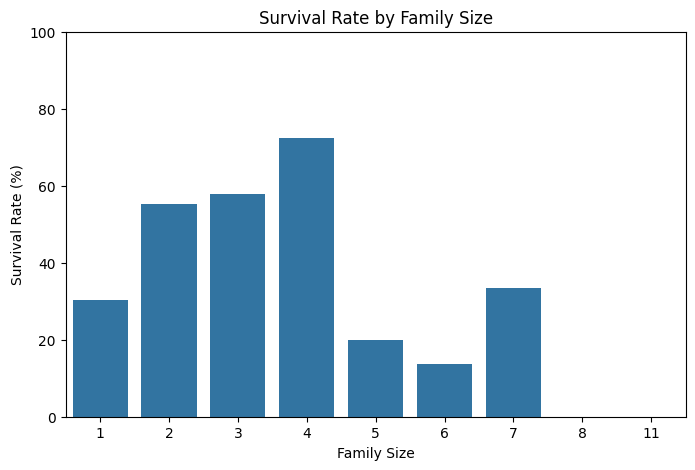

In [53]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=family_survival.index,
    y=family_survival.values
)

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.show()

In [54]:
def family_category(size):
    if size == 1:
        return "Alone"
    elif size <= 4:
        return "Small Family"
    else:
        return "Large Family"

df["Family_Category"] = df["FamilySize"].apply(family_category)

In [58]:
family_category_survival = (df.groupby('Family_Category')['Survived'].mean().mul(100).round(2))
family_category_survival

,Survived
Family_Category,
Alone,30.35
Large Family,16.13
Small Family,57.88


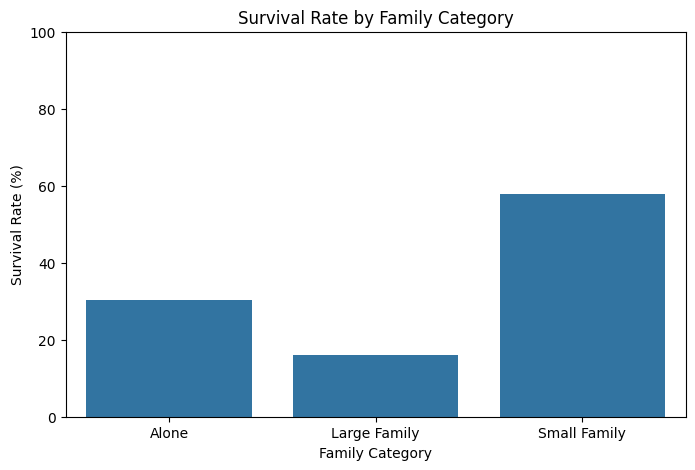

In [65]:
plt.figure(figsize=(8, 5))
sns.barplot(x=family_category_survival.index, y=family_category_survival.values)
plt.title("Survival Rate by Family Category")
plt.xlabel("Family Category")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.show()

#Observation:
###Most passengers were traveling alone, with 537 passengers having a family size of 1. Alone passengers had a lower survival rate of around 30%. Passengers with small families had the highest survival rate, especially family sizes 2, 3, and 4. Large families had much lower survival rates, and some very large family sizes had 0% survival, although their passenger counts were very small.

#Insight:
###Family size had an important effect on survival. Passengers traveling with small families had better survival chances than passengers traveling alone or with large families. This suggests that having some family support may have helped during evacuation, but very large families may have faced difficulty staying together and escaping safely. However, very large family groups had small sample sizes, so their survival rates should be interpreted carefully.

#Correlation Heatmap

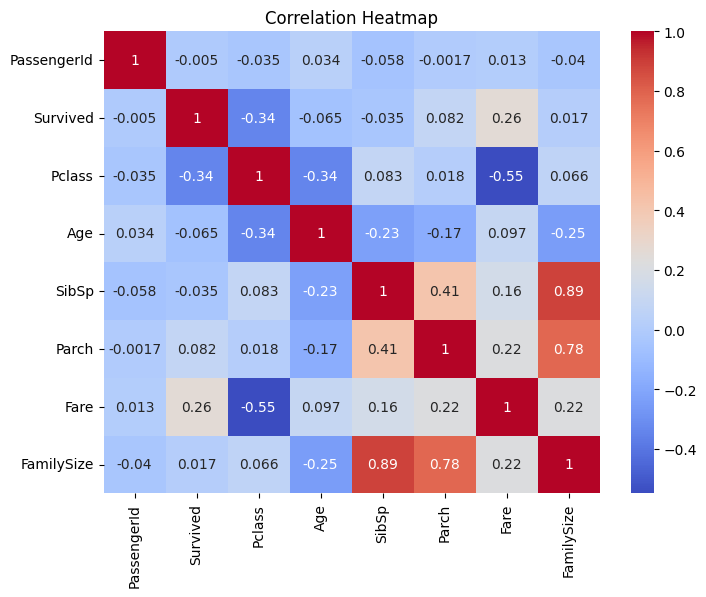

In [66]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Professional Observations and Insights

## 1. Overall Survival Pattern

**Observation:**  
The dataset contains 891 passengers. Out of these, 342 passengers survived and 549 passengers did not survive. This means the overall survival rate was approximately **38.38%**, while around **61.62%** of passengers did not survive.

**Insight:**  
The Titanic disaster had a low overall survival rate. This makes it important to identify which passenger characteristics were strongly associated with survival.

---

## 2. Survival by Gender

**Observation:**  
Female passengers had a much higher survival rate than male passengers. Around **74.20%** of female passengers survived, while only around **18.89%** of male passengers survived.

**Insight:**  
Gender was one of the strongest factors affecting survival. The much higher survival rate among females suggests that women were likely given priority during evacuation and lifeboat boarding.

---

## 3. Survival by Passenger Class

**Observation:**  
Passenger class had a clear relationship with survival. First-class passengers had the highest survival rate at around **62.96%**, followed by second-class passengers at around **47.28%**. Third-class passengers had the lowest survival rate at around **24.24%**.

**Insight:**  
Higher-class passengers had better survival chances. This may be connected to better cabin locations, easier access to lifeboats, and differences in rescue priority. Passenger class is therefore an important feature in survival analysis.

---

## 4. Survival by Gender and Passenger Class

**Observation:**  
When gender and class were analyzed together, first-class and second-class female passengers had the highest survival rates. Female passengers in first class had a survival rate of around **96.81%**, and female passengers in second class had a survival rate of around **92.11%**. In contrast, male passengers had much lower survival rates across all classes, especially in second and third class.

**Insight:**  
The combination of gender and passenger class provides a stronger explanation than either feature alone. Being female and belonging to a higher passenger class greatly increased survival chances, while being male and belonging to third class was associated with a very low survival rate.

---

## 5. Survival by Age

**Observation:**  
Most passengers were young adults, mainly between 20 and 35 years. The median age of both survivors and non-survivors was around 28 years. A large spike around age 28 appears because missing age values were filled using the median.

**Insight:**  
Age alone was not the strongest factor because the median age of survivors and non-survivors was very similar. However, age becomes more meaningful when passengers are grouped into age categories and analyzed with other features such as gender and class.

---

## 6. Survival by Age Group

**Observation:**  
Children had the highest survival rate at around **57.97%**, while senior passengers had the lowest survival rate at around **22.73%**. Teenagers had a survival rate of around **42.86%**, young adults around **35.33%**, and adults around **40.00%**.

**Insight:**  
Children had better survival chances, which supports the idea that children were likely prioritized during rescue. Senior passengers had the lowest survival rate, possibly due to evacuation difficulty and lower physical mobility. Still, age should be interpreted together with gender and passenger class for stronger conclusions.

---

## 7. Survival by Embarked Port

**Observation:**  
Most passengers boarded from Southampton. Passenger counts by port were: Southampton **646**, Cherbourg **168**, and Queenstown **77**. Cherbourg had the highest survival rate at **55.36%**, followed by Queenstown at **38.96%**, and Southampton at **33.90%**.

**Insight:**  
Embarked port appeared to be related to survival, but it should not be interpreted as a direct cause. The survival difference between ports was influenced by other variables such as passenger class and gender.

---

## 8. Embarked Port and Passenger Class

**Observation:**  
Cherbourg had the highest proportion of first-class passengers, with around **50.60%** of its passengers belonging to first class. Queenstown had mostly third-class passengers, around **93.51%**. Southampton also had a majority of third-class passengers, around **54.64%**.

**Insight:**  
Cherbourg's higher survival rate can be partly explained by its higher proportion of first-class passengers. Since first-class passengers had better survival chances, the embarked port effect is strongly connected with passenger class.

---

## 9. Embarked Port and Gender

**Observation:**  
Queenstown had a higher female passenger percentage than Southampton. Queenstown had around **46.75%** female passengers, while Southampton had around **31.73%** female passengers.

**Insight:**  
Queenstown had a slightly higher survival rate than Southampton even though it had mostly third-class passengers. This can be explained by its higher proportion of female passengers and smaller passenger count. Since female passengers had much higher survival chances, Queenstown’s survival rate became higher than Southampton’s.

---

## 10. Survival by Fare

**Observation:**  
Fare distribution was highly right-skewed. Most passengers paid low fares, while only a few passengers paid very high fares. Survivors had a higher average fare of around **48.40**, compared to around **22.12** for non-survivors. The median fare was also higher for survivors.

Fare group survival rates showed a clear increasing pattern:

| Fare Group | Survival Rate |
|---|---:|
| Very Low | 19.94% |
| Low | 43.30% |
| Medium | 48.21% |
| High | 62.32% |
| Very High | 73.58% |

**Insight:**  
Passengers who paid higher fares generally had better survival rates. However, fare should not be interpreted alone because higher fares are strongly connected with higher passenger class. Therefore, fare is an important feature, but its relationship with survival is partly explained by class.

---

## 11. Survival by Family Size

**Observation:**  
Most passengers were traveling alone. There were **537** passengers with a family size of 1. Alone passengers had a survival rate of around **30.35%**. Passengers with small families had the highest survival rate at around **57.88%**, while passengers with large families had a much lower survival rate of around **16.13%**.

**Insight:**  
Passengers traveling with small family sizes had better individual survival rates than passengers traveling alone or with large families. This may suggest that having some family support helped during evacuation, while very large families may have faced difficulty staying together and escaping safely. However, very large family groups had small sample sizes, so those results should be interpreted carefully.

**Important Note:**  
Each row in the dataset represents one passenger, not one family. Therefore, family size values can repeat for members of the same family. This analysis shows individual survival rate by family size, not survival of entire families as complete units.

---

## 12. Correlation Heatmap

**Observation:**  
The correlation heatmap helps compare numerical features. Survival shows a positive relationship with Fare and a negative relationship with Pclass. This means higher fares were generally associated with higher survival, while higher Pclass number, especially class 3, was associated with lower survival.

**Insight:**  
The heatmap supports earlier findings: fare and passenger class were important survival-related features. However, correlation only measures linear relationships between numerical columns, so categorical analysis using groupby, crosstab, and visualizations is also necessary.

---

# Final Conclusion

Titanic survival was influenced by multiple factors, not just one variable. The strongest survival patterns were found in **gender** and **passenger class**. Female passengers and first-class passengers had much higher survival rates. Age, fare, embarked port, and family size also showed meaningful patterns, but these features should be interpreted together because many of them are connected.

Overall, the analysis shows that passengers had higher survival chances if they were female, belonged to a higher passenger class, paid higher fares, were children, or traveled with a small family. Passengers who were male, third class, traveling alone, or part of very large families had lower survival chances.
